## Overview
This notebook trains the CNN on CIFAR-10 and evaluates performance:
- Train on training set
- Monitor validation performance
- Evaluate on test set (unseen data)
- Generate visualizations: learning curves, confusion matrix, per-class metrics
## Methodology
1. **Training Phase:** Minimize loss on training set
2. **Validation Phase:** Monitor generalization, prevent overfitting
3. **Testing Phase:** Final evaluation on held-out test set
4. **Analysis:** Understand model strengths/weaknesses by class

In [ ]:
import os
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set working directory
project_root = r'C:\Users\umroot\cnn-adversarial-robustness\Robustness-of-Convolutional-Neural-Networks-Under-Adversarial-Perturbations'
os.chdir(project_root)

print(f" Working directory: {os.getcwd()}")

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('figures', exist_ok=True)

# Load data
with open('data/processed/cifar10_preprocessed.pkl', 'rb') as f:
    data = pickle.load(f)
    X_train = data['X_train']
    y_train = data['y_train']
    X_val = data['X_val']
    y_val = data['y_val']
    X_test = data['X_test']
    y_test = data['y_test']
    class_names = data['class_names']

# Load UNTRAINED model (from Notebook 03)
model = keras.models.load_model('models/cnn_architecture.keras')

print("Data and model loaded")
print(f"Training: {X_train.shape} | Validation: {X_val.shape} | Test: {X_test.shape}")

✓ Working directory: C:\Users\umroot\cnn-adversarial-robustness\Robustness-of-Convolutional-Neural-Networks-Under-Adversarial-Perturbations
Data and model loaded
Training: (40000, 32, 32, 3) | Validation: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)


In [29]:
plt.savefig('figures/1_sample_images.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/2_class_distribution.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/3_pixel_distribution.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/4_brightness_analysis.png', dpi=300, bbox_inches='tight')

print("\n DATA QUALITY VERIFICATION")
print(f"  Missing values (training): {np.isnan(X_train).sum()}")
print(f"  Missing values (test): {np.isnan(X_test).sum()}")
unique, counts = np.unique(y_train, return_counts=True)
print(f"  Class balance: {'PERFECT' if len(set(counts)) == 1 else 'IMBALANCED'}")
print(f"  Data type correct: {X_train.dtype == np.float32}")
print(f"  Value range correct: {X_train.min() >= 0 and X_train.max() <= 1}")

print("\nGenerated files:")
print("  - figures/1_sample_images.png")
print("  - figures/2_class_distribution.png")
print("  - figures/3_pixel_distribution.png")
print("  - figures/4_brightness_analysis.png")


 DATA QUALITY VERIFICATION
  Missing values (training): 0
  Missing values (test): 0
  Class balance: PERFECT
  Data type correct: True
  Value range correct: True

Generated files:
  - figures/1_sample_images.png
  - figures/2_class_distribution.png
  - figures/3_pixel_distribution.png
  - figures/4_brightness_analysis.png


<Figure size 640x480 with 0 Axes>

## Training Strategy & Hyperparameters
### Hyperparameter Justification
**Learning Rate: 0.001**
- Balances speed (not too slow) with stability (not too fast)
- Standard for Adam optimizer with small networks
- Alternative: Learning rate scheduling (decay over epochs)
**Batch Size: 128**
- Trade-off between memory efficiency and gradient stability
- Typical: 32-256 for moderate-sized datasets
- Smaller batches = more noisy gradients but better generalization
**Epochs: 100**
- Enough to reach convergence without excessive training
- Early stopping will halt if validation loss stops improving
- Prevents unnecessary computation
**Optimizer: Adam**
- Adaptive learning rates per parameter
- Combines momentum (SGD) with adaptive rates (RMSprop)
- Robust across different dataset types
**Loss Function: Sparse Categorical Crossentropy**
- Designed for multi-class classification with integer labels
- Preferred when classes are mutually exclusive (which they are)
### Validation Strategy
- Monitor accuracy and loss on validation set every epoch
- Use early stopping: Stop if validation loss doesn't improve for 10 epochs
- Prevents overfitting while maximizing performance
### Why This Matters for Robustness
- Well-trained model generalizes better to adversarial examples
- Regularization (Dropout) learned during training helps robustness
- Validation set ensures model hasn't overfit to training set peculiarities

In [30]:
# Check current working directory
print("Current working directory:")
print(os.getcwd())

# List files in current directory
print("\nFiles in current directory:")
print(os.listdir('.'))

Current working directory:
C:\Users\umroot\cnn-adversarial-robustness\Robustness-of-Convolutional-Neural-Networks-Under-Adversarial-Perturbations

Files in current directory:
['.git', '.venv', '01_Data_Loading_and_EDA.ipynb', '02_Data_Preprocessing.ipynb', '03_CNN_Model.ipynb', '04_Training_and_Evaluation.ipynb', '05_Adversarial_Perturbations.ipynb', '06_Robustness_Evaluation.ipynb', '1_sample_images.png', '2_class_distribution.png', '3_pixel_distribution.png', '4_brightness_analysis.png', 'data', 'figures', 'models', 'notebook', 'README.md', 'requirement.txt', 'results', 'src']


In [31]:

## Training the CNN

# Early stopping callback
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("\n" + "="*30)
print("TRAINING CNN ON CIFAR-10")
print("="*30)
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Batch size: 128 → {len(X_train) // 128} batches per epoch")

# Train model
history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

print("\n Training complete")
print(f"Epochs trained: {len(history.history['loss'])}")


TRAINING CNN ON CIFAR-10
Training samples: 40000
Validation samples: 10000
Batch size: 128 → 312 batches per epoch
Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.3662 - loss: 1.7196 - val_accuracy: 0.4988 - val_loss: 1.3873
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5196 - loss: 1.3341 - val_accuracy: 0.6034 - val_loss: 1.1156
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5831 - loss: 1.1716 - val_accuracy: 0.6422 - val_loss: 1.0083
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6241 - loss: 1.0638 - val_accuracy: 0.6577 - val_loss: 0.9566
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6502 - loss: 0.9926 - val_accuracy: 0.6855 - val_loss: 0.8966
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6758 - loss: 0.9204 - val_accuracy: 0.7124 - val_loss: 0.8285
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6946 - loss: 0.8689 - val_accuracy: 


## Learning Curves Analysis
**What to Look For:**
1. **Training Loss:** Should decrease smoothly toward zero
2. **Validation Loss:** Should decrease but may plateau (expected)
3. **Overfitting:** Large gap between training and validation loss
4. **Convergence:** Loss stabilizes (training complete)
**Our Model:**
- If training loss >> validation loss: Model is overfitting
- If they track together: Good generalization
- If both high: Model hasn't learned enough


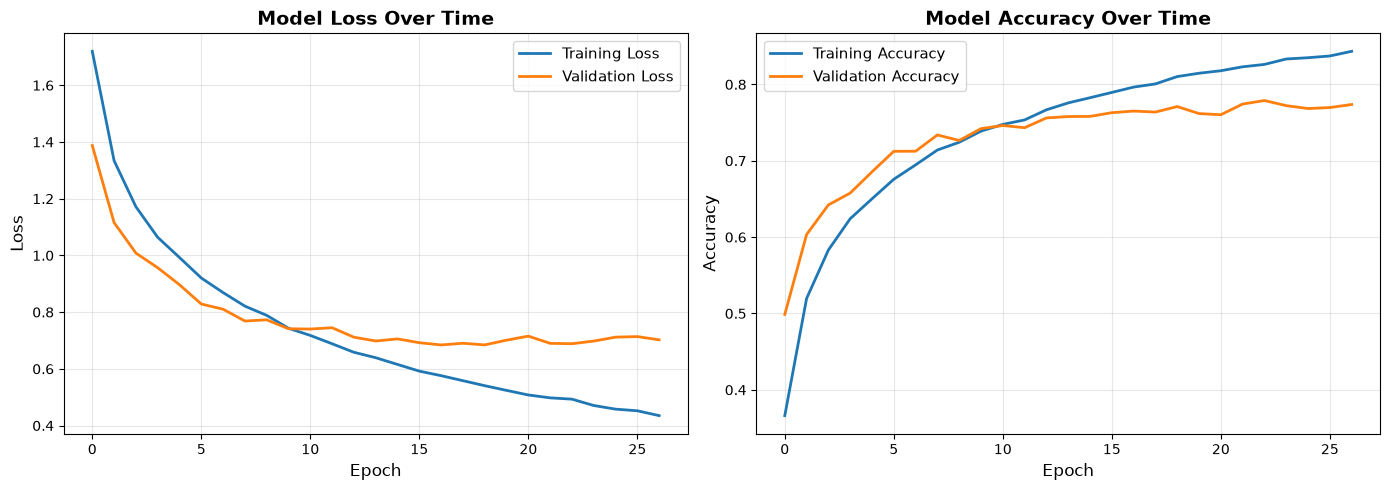

 Saved: figures/04_learning_curves.png

TRAINING SUMMARY
Final Training Loss: 0.4351
Final Validation Loss: 0.7024
Final Training Accuracy: 0.8433
Final Validation Accuracy: 0.7737


In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/04_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: figures/04_learning_curves.png")

# Print final metrics
print("\n" + "="*30)
print("TRAINING SUMMARY")
print("="*30)
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## Evaluation on Test Set (Held-Out Data)
**Critical:** Test set has never been seen by model during training or validation.
This is our FINAL, UNBIASED evaluation.
**Metrics Computed:**
- Accuracy: % of correct predictions
- Per-class Precision: TP / (TP + FP) - false positive rate
- Per-class Recall: TP / (TP + FN) - false negative rate
- F1-Score: Harmonic mean of precision and recall
- Confusion Matrix: Visualize class-level performance

In [33]:
print("\n" + "="*30)
print("TEST SET EVALUATION (FINAL, UNBIASED)")
print("="*30)

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Overall accuracy
test_acc = accuracy_score(y_test, y_pred)
test_loss = model.evaluate(X_test, y_test, verbose=0)[0]

print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# Per-class metrics
print("\n" + "-"*30)
print("PER-CLASS PERFORMANCE")
print("-"*30)

report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)


TEST SET EVALUATION (FINAL, UNBIASED)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Test Accuracy: 0.7573 (75.73%)
Test Loss: 0.7060

------------------------------
PER-CLASS PERFORMANCE
------------------------------
              precision    recall  f1-score   support

    airplane     0.8132    0.7660    0.7889      1000
  automobile     0.8775    0.8450    0.8609      1000
        bird     0.6975    0.6180    0.6554      1000
         cat     0.6065    0.5070    0.5523      1000
        deer     0.6540    0.7730    0.7085      1000
         dog     0.6224    0.7070    0.6620      1000
        frog     0.7884    0.8570    0.8213      1000
       horse     0.8182    0.8010    0.8095      1000
        ship     0.8495    0.8690    0.8591      1000
       truck     0.8592    0.8300    0.8444      1000

    accuracy                         0.7573     10000
   macro avg     0.7586    0.7573    0.7562     10000
weighted avg     0.7586    0.7573    0.7562     10000



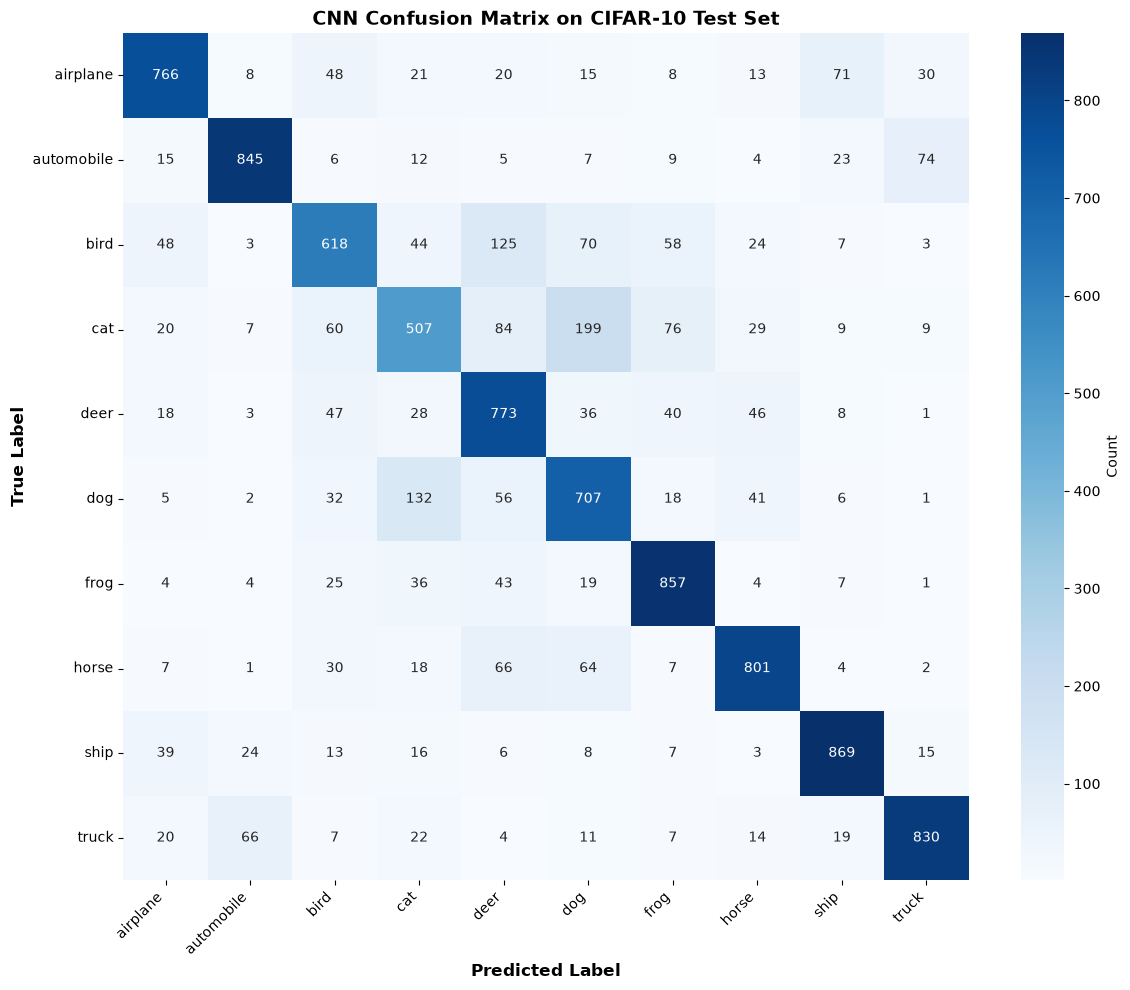

Saved: figures/04_confusion_matrix.png

------------------------------
KEY CONFUSION PATTERNS
------------------------------
airplane     → ship        :  71 errors
automobile   → truck       :  74 errors
bird         → deer        : 125 errors
cat          → dog         : 199 errors
deer         → bird        :  47 errors
dog          → cat         : 132 errors
frog         → deer        :  43 errors
horse        → deer        :  66 errors
ship         → airplane    :  39 errors
truck        → automobile  :  66 errors


In [34]:

## Confusion Matrix Visualization

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('CNN Confusion Matrix on CIFAR-10 Test Set', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/04_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: figures/04_confusion_matrix.png")

# Analyze confusion patterns
print("\n" + "-"*30)
print("KEY CONFUSION PATTERNS")
print("-"*30)

for i in range(len(class_names)):
    # Most confused class
    max_confusion_idx = np.argmax(cm[i, :i] .tolist() + [0] + cm[i, i+1:].tolist())
    max_confusion_count = cm[i, max_confusion_idx]
    if max_confusion_count > 0:
        print(f"{class_names[i]:12s} → {class_names[max_confusion_idx]:12s}: {max_confusion_count:3d} errors")


## Per-Class Performance Analysis
**This is connected to Assignment 1 Findings:**
from EDA:
- Airplane & Ship: Bright images (mean brightness 0.55+)
- Frog & Deer: Dark images (mean brightness <0.45)

**Question:** Does brightness influence CNN accuracy?
- Bright classes (airplane, ship) might be easier to classify
- Dark classes (frog, deer) might be harder



PER-CLASS ACCURACY RANKING
     Class  Accuracy  Count
      ship     0.869   1000
      frog     0.857   1000
automobile     0.845   1000
     truck     0.830   1000
     horse     0.801   1000
      deer     0.773   1000
  airplane     0.766   1000
       dog     0.707   1000
      bird     0.618   1000
       cat     0.507   1000


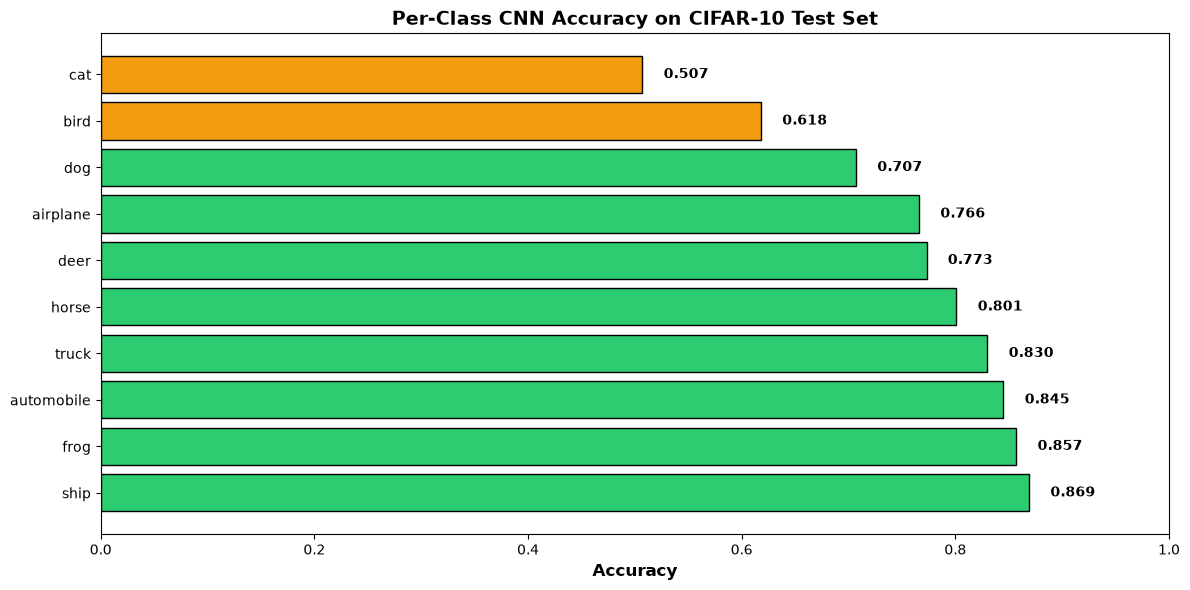

Saved: figures/04_per_class_accuracy.png

------------------------------
INSIGHTS
------------------------------
 Best: ship         (86.9% accuracy)
 Worst: cat          (50.7% accuracy)
Gap: 36.2%


In [35]:
# Compute per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# Sort by accuracy
class_acc_df = pd.DataFrame({
    'Class': class_names,
    'Accuracy': per_class_acc,
    'Count': cm.sum(axis=1)
})
class_acc_df = class_acc_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*30)
print("PER-CLASS ACCURACY RANKING")
print("="*30)
print(class_acc_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if acc > 0.7 else '#f39c12' if acc > 0.5 else '#e74c3c' 
          for acc in class_acc_df['Accuracy']]
bars = ax.barh(class_acc_df['Class'], class_acc_df['Accuracy'], color=colors, edgecolor='black')
ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Per-Class CNN Accuracy on CIFAR-10 Test Set', fontsize=14, fontweight='bold')
ax.set_xlim([0, 1])
for i, (acc, name) in enumerate(zip(class_acc_df['Accuracy'], class_acc_df['Class'])):
    ax.text(acc + 0.02, i, f'{acc:.3f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/04_per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: figures/04_per_class_accuracy.png")

# Analysis
print("\n" + "-"*30)
print("INSIGHTS")
print("-"*30)
best_class = class_acc_df.iloc[0]
worst_class = class_acc_df.iloc[-1]
print(f" Best: {best_class['Class']:12s} ({best_class['Accuracy']:.1%} accuracy)")
print(f" Worst: {worst_class['Class']:12s} ({worst_class['Accuracy']:.1%} accuracy)")
print(f"Gap: {(best_class['Accuracy'] - worst_class['Accuracy']):.1%}")

In [37]:

os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Save trained model
model.save('models/cnn_trained.keras')

# Save results dictionary
results = {
    'test_accuracy': test_acc,
    'test_loss': test_loss,
    'y_pred': y_pred,
    'y_pred_probs': y_pred_probs,
    'per_class_acc': per_class_acc,
    'confusion_matrix': cm,
    'history': history.history
}

with open('results/training_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print(" Trained model saved to 'models/cnn_trained.keras'")
print("Results saved to 'results/training_results.pkl'")

 Trained model saved to 'models/cnn_trained.keras'
Results saved to 'results/training_results.pkl'
